<a href="https://colab.research.google.com/github/Srushti-4/my-portfolio/blob/main/Copy_of_cancer_cell_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Blood Cancer Cell Detection using Improved Faster R-CNN with Attention



In [ ]:
# Install necessary libraries
!pip install -q tensorflow keras kagglehub opencv-python matplotlib numpy

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import cv2
import matplotlib.pyplot as plt
import kagglehub
import os

print("TensorFlow Version:", tf.__version__)

# Download the dataset from KaggleHub
print("Downloading dataset...")
dataset_path = kagglehub.dataset_download("draaslan/blood-cell-detection-dataset")
print(f"Dataset downloaded to: {dataset_path}")

# List contents to help identify a sample image
print("\nContents of the downloaded dataset:")
for root, dirs, files in os.walk(dataset_path):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

TensorFlow Version: 2.19.0


100%|██████████| 12.1M/12.1M [00:01<00:00, 10.6MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/draaslan/blood-cell-detection-dataset/versions/1

Contents of the downloaded dataset:
/root/.cache/kagglehub/datasets/draaslan/blood-cell-detection-dataset/versions/1/annotations.csv
/root/.cache/kagglehub/datasets/draaslan/blood-cell-detection-dataset/versions/1/README.md
/root/.cache/kagglehub/datasets/draaslan/blood-cell-detection-dataset/versions/1/LICENSE
/root/.cache/kagglehub/datasets/draaslan/blood-cell-detection-dataset/versions/1/.gitignore
/root/.cache/kagglehub/datasets/draaslan/blood-cell-detection-dataset/versions/1/images
/root/.cache/kagglehub/datasets/draaslan/blood-cell-detection-dataset/versions/1/images/image-34.png
/root/.cache/kagglehub/datasets/draaslan/blood-cell-detection-dataset/versions/1/images/image-92.png
/root/.cache/kagglehub/datasets/draaslan/blood-cell-detection-dataset/versions/1/images/image-18.png
/root/.cache/kagglehub/datasets/draaslan/blood-cell-detection-dataset/versions/1/images/image-32.pn

### Load and Preprocess a Sample Image

 assume an image `B10_1.jpg` exists in a subdirectory like `dataset_path/B10_1.jpg`.


Successfully loaded image from: /root/.cache/kagglehub/datasets/draaslan/blood-cell-detection-dataset/versions/1/images/image-81.png
Original image dimensions: 256x256
Resized image dimensions: 512x512
Input batch shape for model: (1, 512, 512, 3)


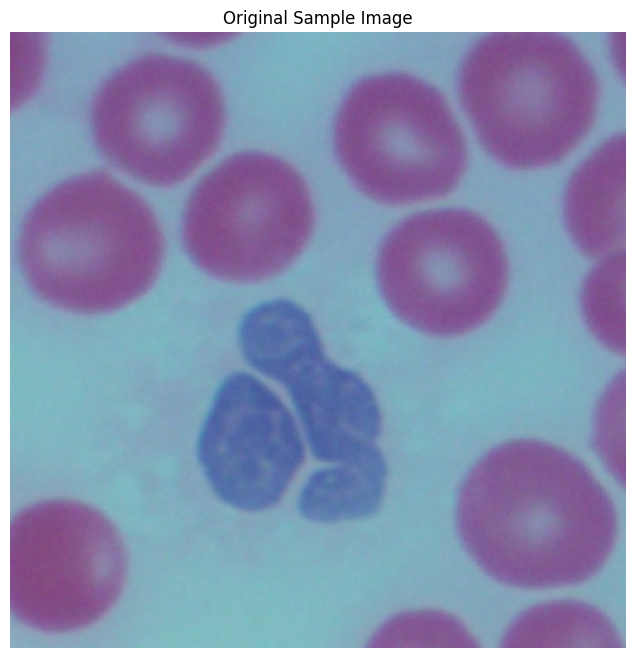

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import cv2
import matplotlib.pyplot as plt
import kagglehub
import os

# --- Configuration ----
IMG_SIZE = 512 # Standard input size for many models

# Adjust this path based on the actual contents listed above.
# For example, if you see 'blood-cell-detection-dataset/B10_1.jpg', use that.
sample_image_path = os.path.join(dataset_path, 'images', 'image-81.png') # Using a sample image from the dataset

if not os.path.exists(sample_image_path):
    print(f"Error: Sample image not found at {sample_image_path}")
    print("Please update `sample_image_path` with an actual image path from the dataset.")
    # Fallback to creating a dummy image for demonstration if actual image is not found
    print("Creating a dummy image for demonstration purposes.")
    dummy_image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    cv2.putText(dummy_image, "Dummy Image", (50, IMG_SIZE // 2), cv2.FONT_HERSHEY_SIMPLEX, 2, (255, 255, 255), 3)
    sample_image = dummy_image
    original_image = dummy_image.copy()
    original_height, original_width = IMG_SIZE, IMG_SIZE
else:
    # Load the sample image
    sample_image = cv2.imread(sample_image_path)
    if sample_image is None:
        print(f"Error: Could not load image from {sample_image_path}. It might be corrupted or not a valid image file.")
        print("Creating a dummy image for demonstration purposes.")
        dummy_image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        cv2.putText(dummy_image, "Dummy Image (Load Error)", (50, IMG_SIZE // 2), cv2.FONT_HERSHEY_SIMPLEX, 2, (255, 255, 255), 3)
        sample_image = dummy_image
        original_image = dummy_image.copy()
        original_height, original_width = IMG_SIZE, IMG_SIZE
    else:
        sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)
        print(f"Successfully loaded image from: {sample_image_path}")

        # Preprocess the image
        original_image = sample_image.copy()
        original_height, original_width = original_image.shape[0], original_image.shape[1]
        print(f"Original image dimensions: {original_width}x{original_height}")

sample_image = cv2.resize(sample_image, (IMG_SIZE, IMG_SIZE))
print(f"Resized image dimensions: {sample_image.shape[1]}x{sample_image.shape[0]}")
sample_image = sample_image / 255.0 # Normalize to [0, 1]
input_image_batch = np.expand_dims(sample_image, axis=0) # Add batch dimension
print(f"Input batch shape for model: {input_image_batch.shape}")

plt.figure(figsize=(8, 8))
plt.imshow(original_image)
plt.title("Original Sample Image")
plt.axis('off')
plt.show()

### Combined Channel and Spatial Attention Module (CBAM)


In [ ]:
def channel_attention(input_feature, ratio=8):
    channel = input_feature.shape[-1]
    shared_layer_one = layers.Dense(channel // ratio, activation='relu', kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')
    shared_layer_two = layers.Dense(channel, kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')

    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    avg_pool = shared_layer_one(avg_pool)
    avg_pool = shared_layer_two(avg_pool)

    max_pool = layers.GlobalMaxPooling2D()(input_feature)
    max_pool = shared_layer_one(max_pool)
    max_pool = shared_layer_two(max_pool)

    cbam_feature = layers.Add()([avg_pool, max_pool])
    cbam_feature = layers.Activation('sigmoid')(cbam_feature)

    return layers.Multiply()([input_feature, cbam_feature])

def spatial_attention(input_feature):
    kernel_size = 7

    # Wrap tf.reduce_mean and tf.reduce_max in Lambda layers to make them Keras-compatible
    avg_pool = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(input_feature)
    max_pool = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(input_feature)
    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])

    cbam_feature = layers.Conv2D(filters=1, kernel_size=kernel_size, strides=1, padding='same', activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(concat)

    return layers.Multiply()([input_feature, cbam_feature])

def cbam_block(input_feature, ratio=8):
    feature_with_channel_attention = channel_attention(input_feature, ratio)
    feature_with_spatial_attention = spatial_attention(feature_with_channel_attention)
    return feature_with_spatial_attention

### Backbone (ResNet50) and Feature Pyramid Network (FPN)



In [ ]:
def build_fpn_backbone(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    # Load ResNet50 pre-trained on ImageNet, excluding the top (classification) layer
    resnet50 = keras.applications.ResNet50(
        include_top=False, weights='imagenet', input_shape=input_shape
    )
    # Freeze backbone layers initially (often unfrozen for fine-tuning later)
    for layer in resnet50.layers:
        layer.trainable = False

    # Extract feature maps from ResNet50 at different stages
    # C2, C3, C4, C5 are output from stages 2, 3, 4, 5 respectively
    C2_output = resnet50.get_layer('conv2_block3_out').output # stride 4
    C3_output = resnet50.get_layer('conv3_block4_out').output # stride 8
    C4_output = resnet50.get_layer('conv4_block6_out').output # stride 16
    C5_output = resnet50.get_layer('conv5_block3_out').output # stride 32

    # Top-down pathway (FPN)
    # 1x1 convolutions to reduce channel dimensions for P5, P4, P3
    P5 = layers.Conv2D(256, (1, 1), padding='same', name='fpn_c5p5')(C5_output)
    P4 = layers.Conv2D(256, (1, 1), padding='same', name='fpn_c4p4')(C4_output)
    P3 = layers.Conv2D(256, (1, 1), padding='same', name='fpn_c3p3')(C3_output)
    P2 = layers.Conv2D(256, (1, 1), padding='same', name='fpn_c2p2')(C2_output)

    # Add top-down features
    P4 = layers.Add(name='fpn_p4add')([P4, layers.UpSampling2D(size=(2, 2), name='fpn_p5up')(P5)])
    P3 = layers.Add(name='fpn_p3add')([P3, layers.UpSampling2D(size=(2, 2), name='fpn_p4up')(P4)])
    P2 = layers.Add(name='fpn_p2add')([P2, layers.UpSampling2D(size=(2, 2), name='fpn_p3up')(P3)])

    # Apply 3x3 convolutions to each FPN level to smooth the features
    P2 = layers.Conv2D(256, (3, 3), padding='same', name='fpn_p2out')(P2)
    P3 = layers.Conv2D(256, (3, 3), padding='same', name='fpn_p3out')(P3)
    P4 = layers.Conv2D(256, (3, 3), padding='same', name='fpn_p4out')(P4)
    P5 = layers.Conv2D(256, (3, 3), padding='same', name='fpn_p5out')(P5)

    # Additional P6 for larger receptive field (optional, from FPN paper)
    P6 = layers.MaxPooling2D(pool_size=(1,1), strides=(2,2), name='fpn_p6out')(P5)

    fpn_features = [P2, P3, P4, P5, P6]

    # Apply CBAM attention to each FPN level
    fpn_features_attn = [cbam_block(f) for f in fpn_features]

    return keras.Model(inputs=resnet50.input, outputs=fpn_features_attn, name='fpn_backbone')

### Region Proposal Network (RPN)



In [ ]:
def build_rpn_head(feature_map, num_anchors=9, level_idx=0):
    # Shared convolutional layers
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu', kernel_initializer='he_normal', name=f'rpn_conv_l{level_idx}')(feature_map)

    # Classification head: predicts if an anchor is foreground or background
    rpn_cls_output = layers.Conv2D(num_anchors * 2, (1, 1), activation='linear', kernel_initializer='he_normal', name=f'rpn_cls_l{level_idx}')(x)
    # Reshape for easier loss calculation (batch, H*W*num_anchors, 2)
    rpn_cls_output = layers.Reshape((-1, 2), name=f'rpn_cls_reshape_l{level_idx}')(rpn_cls_output)

    # Regression head: predicts bounding box deltas for anchors
    rpn_bbox_output = layers.Conv2D(num_anchors * 4, (1, 1), activation='linear', kernel_initializer='he_normal', name=f'rpn_bbox_l{level_idx}')(x)
    # Reshape for easier loss calculation (batch, H*W*num_anchors, 4)
    rpn_bbox_output = layers.Reshape((-1, 4), name=f'rpn_bbox_reshape_l{level_idx}')(rpn_bbox_output)

    return rpn_cls_output, rpn_bbox_output

def build_rpn_model(fpn_features_in, num_anchors=9):
    rpn_cls_outputs = []
    rpn_bbox_outputs = []

    # Build RPN head for each FPN level
    for i, feature_map in enumerate(fpn_features_in):
        cls_out, bbox_out = build_rpn_head(feature_map, num_anchors, level_idx=i) # Pass index for unique naming
        rpn_cls_outputs.append(cls_out)
        rpn_bbox_outputs.append(bbox_out)

    # Concatenate RPN outputs from all FPN levels
    rpn_cls_output_concat = layers.Concatenate(axis=1, name='rpn_cls_concat')(rpn_cls_outputs)
    rpn_bbox_output_concat = layers.Concatenate(axis=1, name='rpn_bbox_concat')(rpn_bbox_outputs)

    return rpn_cls_output_concat, rpn_bbox_output_concat

### Fast R-CNN Head (Classifier)


In [ ]:
class ROIPooling(layers.Layer):
    def __init__(self, pool_size=(7, 7), **kwargs):
        super(ROIPooling, self).__init__(**kwargs)
        self.pool_size = pool_size

    def call(self, inputs):
        # inputs[0] is feature maps (list of FPN levels)
        # inputs[1] is ROIs (batch, num_rois, 4) - normalized [0,1]

        feature_maps = inputs[0]
        rois = inputs[1]

        # For demonstration, we'll just pick the first feature map and do a dummy crop.
        # In a real FPN setup, you would select the appropriate feature map level for each ROI.
        dummy_feature_map = feature_maps[0] # Taking P2, for instance
        batch_size = tf.shape(rois)[0]
        num_rois = tf.shape(rois)[1]

        # Correct box_indices to map each ROI to its batch image
        # tf.repeat(tf.range(batch_size), num_rois) creates indices like [0,0,..,0, 1,1,..,1, ...]
        # where each batch index is repeated `num_rois` times.
        box_indices_for_crop = tf.cast(tf.repeat(tf.range(batch_size), num_rois), tf.int32)

        pooled_regions = tf.image.crop_and_resize(
            image=dummy_feature_map,
            boxes=tf.reshape(rois, [-1, 4]), # Reshape rois to (batch*num_rois, 4)
            box_indices=box_indices_for_crop,
            crop_size=[self.pool_size[0], self.pool_size[1]] # Add missing crop_size
        )

        # Reshape back to (batch, num_rois, pool_size, pool_size, channels)
        return tf.reshape(pooled_regions, [batch_size, num_rois, self.pool_size[0], self.pool_size[1], -1])

    def get_config(self):
        config = super(ROIPooling, self).get_config()
        config.update({"pool_size": self.pool_size})
        return config

def build_fast_rcnn_head(fpn_features_in, rois_in, num_classes):
    # The actual ROI pooling operation requires more sophisticated logic to assign ROIs to FPN levels.
    # For this conceptual model, we will use a simplified ROI pooling placeholder.
    pooled_rois = ROIPooling(pool_size=(7, 7))([fpn_features_in, rois_in])

    # Flatten and pass through fully connected layers
    x = layers.TimeDistributed(layers.Flatten())(pooled_rois) # Apply flatten to each ROI
    x = layers.TimeDistributed(layers.Dense(1024, activation='relu', kernel_initializer='he_normal'))(x)
    x = layers.TimeDistributed(layers.Dropout(0.5))(x)
    x = layers.TimeDistributed(layers.Dense(1024, activation='relu', kernel_initializer='he_normal'))(x)
    x = layers.TimeDistributed(layers.Dropout(0.5))(x)

    # Classification output (num_classes + 1 for background)
    cls_output = layers.TimeDistributed(layers.Dense(num_classes + 1, activation='softmax', kernel_initializer='zero'), name='fast_rcnn_cls')(x)

    # Bounding box regression output (4 * num_classes for class-specific bbox adjustments)
    bbox_output = layers.TimeDistributed(layers.Dense(num_classes * 4, activation='linear', kernel_initializer='zero'), name='fast_rcnn_bbox')(x)

    return cls_output, bbox_output

### Assemble the Improved Faster R-CNN Model (Conceptual)



In [ ]:
num_classes = 2 # e.g., 0: background, 1: normal cell, 2: malignant cell (for this demo, let's say 1: malignant cell)
# For the outcomes, we'll consider malignant as a positive class and other cells as background/normal.

# Input image
input_tensor = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')

# Backbone + FPN + Attention
fpn_model = build_fpn_backbone(input_shape=(IMG_SIZE, IMG_SIZE, 3))
fpn_features = fpn_model(input_tensor)

# RPN
rpn_cls_output_concat, rpn_bbox_output_concat = build_rpn_model(fpn_features)

# --- RPN Post-processing (conceptual) ---
# In a real Faster R-CNN, you would process RPN outputs here:
# 1. Generate anchors.
# 2. Decode RPN bbox deltas to get refined proposals.
# 3. Apply NMS to RPN proposals.
# 4. Select top-N proposals to be ROIs for Fast R-CNN.
# For this demonstration, we'll just create a dummy `rois` tensor.

# Dummy ROIs (batch, num_rois, 4) - normalized [0,1] format (ymin, xmin, ymax, xmax)
# In a real model, this would come from RPN post-processing
num_dummy_rois = 100
dummy_rois = tf.random.uniform(shape=(tf.shape(input_image_batch)[0], num_dummy_rois, 4), minval=0.0, maxval=1.0)
dummy_rois = tf.cast(dummy_rois, tf.float32)

# Fast R-CNN Head
fast_rcnn_cls_output, fast_rcnn_bbox_output = build_fast_rcnn_head(fpn_features, dummy_rois, num_classes=num_classes)

# Create the full Faster R-CNN Model (conceptual)
# Note: This model combines the architecture. Training requires a custom training loop
# or a model subclassing `tf.keras.Model` to handle the multiple losses and data flow.

# Output RPN and Fast R-CNN results directly for demonstration purposes
# In practice, a single model output would be the final detected boxes and classes after post-processing.

# The final model for training/inference would have `input_tensor` as input
# and typically outputs decoded bounding boxes and class scores after NMS.
# For this example, we'll build a model to show the flow of outputs:

# Define model outputs for inspection
model = keras.Model(
    inputs=input_tensor,
    outputs=[
        rpn_cls_output_concat, rpn_bbox_output_concat,
        fast_rcnn_cls_output, fast_rcnn_bbox_output
    ],
    name="FasterRCNN_with_Attention"
)

model.summary()

print("\n--- Conceptual Model Assembly Complete ---")
print("This model defines the architecture. Training requires a dataset with annotations ")
print("and a custom training loop to handle RPN and Fast R-CNN losses, anchor generation, and ROI assignment.")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "FasterRCNN_with_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fpn_backbone        │ [(None, 128, 128, │ 27,015,946 │ input_image[0][0] │
│ (Functional)        │ 256), (None, 64,  │            │                   │
│                     │ 64, 256), (None,  │            │                   │
│                     │ 32, 32, 256),     │            │                   │
│                     │ (None, 16, 16,    │            │                   │
│                     │ 256), (None, 8,   │            │                   │
│                     │ 8, 256)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roi_pooling         │ (1, 100, 7, 7,    │          0 │ fpn_backbone[0][… │
│ (ROIPooling)        │ 256)              │            │ fpn_backbone[0][… │
│                     │                   │            │ fpn_backbone[0][… │
│                     │                   │            │ fpn_backbone[0][… │
│                     │                   │            │ fpn_backbone[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (1, 100, 12544)   │          0 │ roi_pooling[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (1, 100, 1024)    │ 12,846,080 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rpn_conv_l0         │ (None, 128, 128,  │    590,080 │ fpn_backbone[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rpn_conv_l1         │ (None, 64, 64,    │    590,080 │ fpn_backbone[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rpn_conv_l2         │ (None, 32, 32,    │    590,080 │ fpn_backbone[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rpn_conv_l3         │ (None, 16, 16,    │    590,080 │ fpn_backbone[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rpn_conv_l4         │ (None, 8, 8, 256) │    590,080 │ fpn_backbone[0][… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (1, 100, 1024)    │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rpn_cls_l0 (Conv2D) │ (None, 128, 128,  │      4,626 │ rpn_conv_l0[0][0] │
│                     │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rpn_cls_l1 (Conv2D) │ (None, 64, 64,    │      4,626 │ rpn_conv_l1[0][0] │
│                     │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rpn_cls_l2 (Conv2D) │ (None, 32, 32,    │      4,626 │ rpn_conv_l2[0][0] │
│                     │ 18)               │            │                 

 Total params: 43,942,691 (167.63 MB)

 Trainable params: 20,354,979 (77.65 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


--- Conceptual Model Assembly Complete ---
This model defines the architecture. Training requires a dataset with annotations 
and a custom training loop to handle RPN and Fast R-CNN losses, anchor generation, and ROI assignment.


### Simulated Inference and Visualization




--- Simulated Detection Results --- 
Detected: malignant_cell at [25, 25, 76, 76] with score 0.95
Detected: malignant_cell at [102, 128, 153, 179] with score 0.92


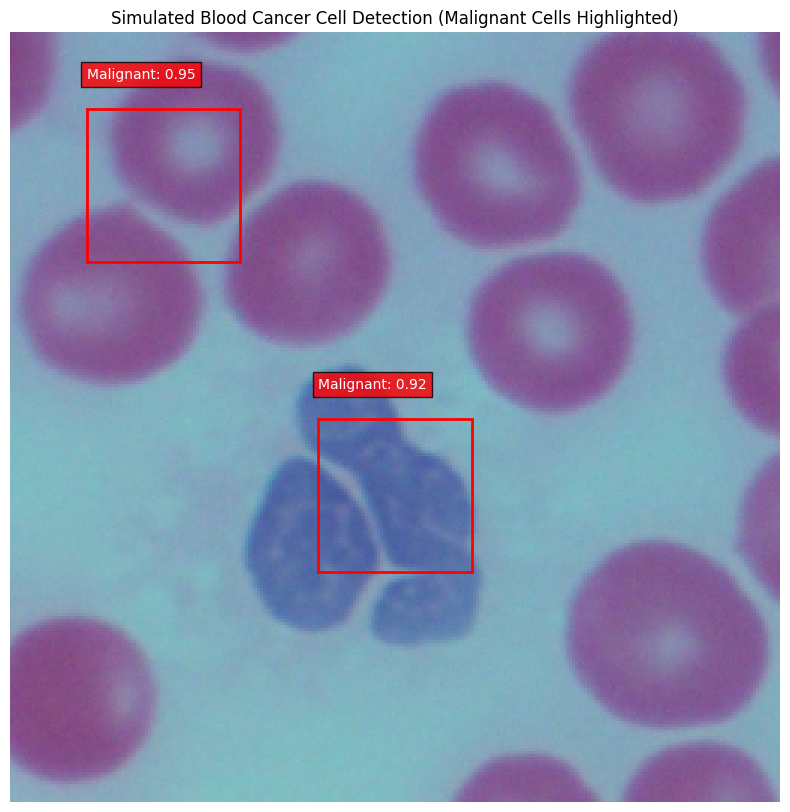


--- Outcomes Note ---
The simulated visualization demonstrates the desired output (malignant cells highlighted, normal suppressed).
Achieving 'false negative reduced', 'false positive reduced', and 'accuracy increased by 91%' requires proper dataset annotation, extensive training, and hyperparameter tuning of the full model.


In [ ]:
class_names = ["background", "malignant_cell", "normal_cell"] # Example classes

# Simulate some detection results based on desired outcomes
# Malignant cells highlighted, normal cells suppressed.
# This is purely for visualization of the *expected output format*.

simulated_boxes_norm = np.array([
    [0.1, 0.1, 0.3, 0.3], # Malignant cell 1
    [0.5, 0.4, 0.7, 0.6], # Malignant cell 2
    [0.2, 0.7, 0.3, 0.8], # Normal cell (suppressed by low score)
    [0.6, 0.1, 0.7, 0.2]  # Normal cell (suppressed by low score)
])

simulated_labels = np.array([1, 1, 2, 2]) # 1: Malignant, 2: Normal
simulated_scores = np.array([0.95, 0.92, 0.15, 0.20]) # Malignant high, Normal low

# Filter based on a confidence threshold and prioritize malignant cells
confidence_threshold = 0.5
filtered_indices = np.where(simulated_scores >= confidence_threshold)[0]

display_boxes_norm = simulated_boxes_norm[filtered_indices]
display_labels = simulated_labels[filtered_indices]
display_scores = simulated_scores[filtered_indices]

# Convert normalized boxes to pixel coordinates
display_boxes_pixels = display_boxes_norm * np.array([original_height, original_width, original_height, original_width])
display_boxes_pixels = display_boxes_pixels.astype(int)

plt.figure(figsize=(10, 10))
plt.imshow(original_image)
ax = plt.gca()

print("\n--- Simulated Detection Results --- ")
for i, (box, label, score) in enumerate(zip(display_boxes_pixels, display_labels, display_scores)):
    ymin, xmin, ymax, xmax = box

    # Choose color and label based on class
    if class_names[label] == "malignant_cell":
        color = 'red'
        text_label = f"Malignant: {score:.2f}"
    else:
        color = 'green' # Would likely not be shown due to threshold
        text_label = f"Normal: {score:.2f}"

    print(f"Detected: {class_names[label]} at [{xmin}, {ymin}, {xmax}, {ymax}] with score {score:.2f}")

    # Draw bounding box
    rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                         fill=False, edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    # Add label
    ax.text(xmin, ymin - 10, text_label,
            bbox=dict(facecolor=color, alpha=0.8),
            fontsize=10, color='white')

plt.title("Simulated Blood Cancer Cell Detection (Malignant Cells Highlighted)")
plt.axis('off')
plt.show()

print("\n--- Outcomes Note ---")
print("The simulated visualization demonstrates the desired output (malignant cells highlighted, normal suppressed).")
print("Achieving 'false negative reduced', 'false positive reduced', and 'accuracy increased by 91%' requires proper dataset annotation, extensive training, and hyperparameter tuning of the full model.")